# Analysis of experiment #7: B&P

## Read data

In [1]:
# Read csv

import pandas as pd
import numpy as np

df = pd.read_csv("stats7.csv")

# Add column with edge probability
df["p"] = df.instance.apply(lambda s: float(s.split("_")[2][1:]))

# Distinguish instances solved by optimality in the root node
df.loc[(df.nodes == 1) & (df.state == "OPTIMAL"), "state"] = "OPTIMAL IN ROOT"

# Join MWISS time
df['rootTimeMwis'] = df['rootTimeMwis1'] + df['rootTimeMwis2']
df['otherNodesTimeMwis'] = df['otherNodesTimeMwis1'] + df['otherNodesTimeMwis2']

In [11]:
df.columns

Index(['instance', 'solver', 'run', 'nvertices', 'nedges', 'nP', 'nQ', 'nvars',
       'ncons', 'state', 'terminationReason', 'time', 'nodes', 'nodesLeft',
       'lb', 'ub', 'gap', 'ninfeas', 'ninfeasPrepro', 'ninfeasCheck',
       'ninfeasAux', 'gcpAvgTime', 'nsol', 'nsolHeur', 'nsolLR', 'nsolGCP',
       'nsolTrivial', 'ntrivialNodes', 'nintNodes', 'nfracNodes', 'ngcpNodes',
       'rootlb', 'rootub', 'rootHeurTime', 'rootFeasTime', 'rootNCalls',
       'rootNCallsPool', 'rootNCallsHeur', 'rootNCallsMwis1',
       'rootNCallsMwis2', 'rootNCallsExact', 'rootNCols', 'rootNColsPool',
       'rootNColsHeur', 'rootNColsMwis1', 'rootNColsMwis2', 'rootNColsExact',
       'rootTime', 'rootTimePool', 'rootTimeHeur', 'rootTimeMwis1',
       'rootTimeMwis2', 'rootTimeExact', 'otherNodesHeurTime',
       'otherNodesFeasNCalls', 'otherNodesFeasTime', 'otherNodesNCalls',
       'otherNodesNCallsPool', 'otherNodesNCallsHeur', 'otherNodesNCallsMwis1',
       'otherNodesNCallsMwis2', 'otherNodesNCal

## Summary

<Axes: >

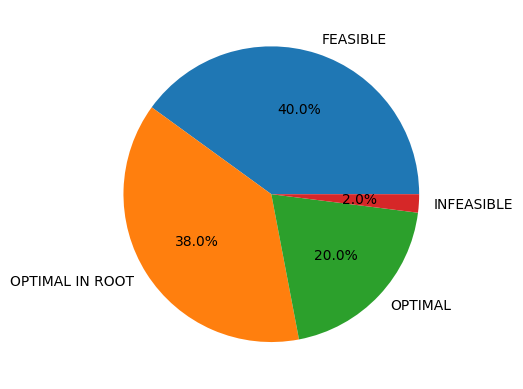

In [2]:
df.state.value_counts().plot.pie(autopct='%1.1f%%')

Nos quedamos con las instancias con estado OPTIMAL o FEASIBLE.

In [3]:
df2 = df[(df.state == "OPTIMAL") | (df.state == "FEASIBLE")]

In [4]:
# Sort values
df2 = df2.sort_values(['nvertices', 'p', 'nP', 'nQ']).reset_index(drop=True)

In [13]:
df3 = df2[['nvertices', 'p', 'nP', 'nQ', 'state', 'nodes', 'nfracNodes', 'nintNodes', 'time', 'gap', 'lb', 'ub', 'rootTime', 'rootTimeHeur', 'rootTimeMwis', 'rootTimeExact', 'otherNodesTime', 'otherNodesTimeHeur', 'otherNodesTimeMwis', 'otherNodesTimeExact']]
columns = [ ('N','',''), ('p','',''), ('n','',''), ('m','',''), ('status','',''), ('nodes','total',''), ('nodes','frac',''), ('nodes','int',''), ('time (s)','',''), ('gap (%)','',''), ('lb','',''), ('ub','',''), ('pricing (s)', 'root', 'total'), ('pricing (s)', 'root', 'heur'), ('pricing (s)', 'root', 'MWSS'), ('pricing (s)', 'root', 'ILP'), ('pricing (s)', 'avg. non-root node', 'total'), ('pricing (s)', 'avg. non-root node', 'heur'), ('pricing (s)', 'avg. non-root node', 'MWSS'), ('pricing (s)', 'avg. non-root node', 'ILP') ]
df3.columns = pd.MultiIndex.from_tuples(columns)
# df3[('nodes','infeas','')] = df3[('nodes','infeas','')].round(0).astype(int)
df3[('time (s)','','')] = df3[('time (s)','','')].round(0).astype(int)
df3[('ub','','')] = df3[('ub','','')].round(0).astype(int)
df3[('gap (%)','','')] = df3[('gap (%)','','')] * 100
df3 = df3.round({('gap (%)','',''): 2, ('lb','',''): 2, ('ub','',''): 2, ('pricing (s)', 'root', 'total'): 2, ('pricing (s)', 'root', 'heur'): 2, ('pricing (s)', 'root', 'MWSS'): 2, ('pricing (s)', 'root', 'ILP'): 2, ('pricing (s)', 'avg. non-root node', 'total'): 1, ('pricing (s)', 'avg. non-root node', 'heur'): 2, ('pricing (s)', 'avg. non-root node', 'MWSS'): 2, ('pricing (s)', 'avg. non-root node', 'ILP'): 1})
df3

c:\Users\Chiodo\git\cpds\.venv\Lib\site-packages\pandas\core\internals\blocks.py:1530: RuntimeWarning: overflow encountered in multiply
  values = self.values.round(decimals)  # type: ignore[union-attr]


N     p   n   m    status nodes          time (s) gap (%)    lb ub  \
                                total frac int                             
                                                                           
0   110  0.25  22  11  FEASIBLE    15   14   0     7200   33.33  2.00  3   
1   110  0.25  22  11  FEASIBLE    25   24   0     7200   33.33  2.00  3   
2   110  0.25  22  11  FEASIBLE     1    0   0     7200     inf  -inf  2   
3   110  0.25  22  11  FEASIBLE    35   34   0     7200   33.33  2.00  3   
4   110  0.25  22  22  FEASIBLE     6    5   0     7200   44.17  1.67  3   
5   110  0.25  22  22   OPTIMAL    19   18   1       19    0.00  2.00  2   
6   120  0.50  24  12  FEASIBLE    57   56   0     7200   26.04  3.70  5   
7   120  0.50  24  12  FEASIBLE    19   18   0     7200   28.08  3.60  5   
8   120  0.50  24  12  FEASIBLE     4    3   0     7200   26.23  3.69  5   
9   120  0.50  24  12  FEASIBLE    74   73   0     7200   20.08  4.00  5   
10  120  0.50  24  12  FEASIBLE   163  162   0     7200   24.28  4.54  6   
11  120  0.50  24  24  FEASIBLE     3    2   0     7200   35.11  3.24  5   
12  120  0.50  24  24  FEASIBLE     2    1   0     7200     inf  -inf  5   
13  120  0.50  24  24  FEASIBLE    12   11   0     7200   37.97  3.10  5   
14  120  0.50  24  24  FEASIBLE    33   32   0     7200   32.72  3.36  5   
15  120  0.50  24  24  FEASIBLE     3    2   0     7200   38.43  3.08  5   
16  130  0.75  13  13   OPTIMAL   109  108   1      427    0.00  3.00  3   
17  130  0.75  13  13   OPTIMAL   107  106   1      360    0.00  3.00  3   
18  130  0.75  13  26   OPTIMAL   177  176   1      348    0.00  3.00  3   
19  130  0.75  13  26   OPTIMAL    11   11   0       93    0.00  3.00  3   
20  130  0.75  13  26   OPTIMAL   173  172   1      343    0.00  3.00  3   
21  130  0.75  13  26   OPTIMAL    93   92   1      263    0.00  3.00  3   
22  130  0.75  26  13   OPTIMAL    25   25   0      448    0.00  9.00  9   
23  130  0.75  26  13   OPTIMAL    15   14   1      273    0.00  9.00  9   
24  130  0.75  26  13   OPTIMAL     5    5   0      157    0.00  8.00  8   
25  130  0.75  26  26  FEASIBLE    87   86   0     7200   14.33  6.00  7   
26  130  0.75  26  26  FEASIBLE    16   15   0     7200   18.66  5.69  7   
27  130  0.75  26  26  FEASIBLE    67   66   0     7200   19.20  5.66  7   
28  130  0.75  26  26  FEASIBLE    59   58   0     7200   22.38  6.21  8   
29  130  0.75  26  26  FEASIBLE    24   23   0     7200   17.09  5.80  7   

   pricing (s)                                                                 
          root                       avg. non-root node                        
         total  heur   MWSS      ILP              total   heur   MWSS     ILP  
0        39.33  0.56   0.14    38.63              510.7   2.67   2.04   505.9  
1        44.78  0.56   0.29    43.93              297.7   1.59   1.32   294.7  
2      7189.43  7.25  17.59  7164.59                0.0   0.00   0.00     0.0  
3        34.62  0.57   0.12    33.93              210.3   1.68   1.02   207.6  
4        12.91  0.47   0.31    12.14             1434.4   8.87  22.07  1403.4  
5         0.08  0.07   0.00     0.01                0.4   0.03   0.00     0.4  
6        98.11  0.53   0.18    97.40              126.4   0.49   0.13   125.8  
7       123.06  0.69   0.10   122.27              392.0   1.13   0.37   390.5  
8        68.51  0.57   0.06    67.88             2370.9   8.06   1.31  2361.5  
9       117.99  0.63   0.07   117.29               96.8   0.46   0.09    96.2  
10       53.74  0.43   0.08    53.23               44.0   0.22   0.06    43.7  
11       42.34  0.42   0.22    41.71             3566.8   6.76  10.01  3550.0  
12       29.08  0.38   0.18    28.51             7147.0  29.38  41.34  7076.0  
13       26.38  0.40   0.19    25.79              649.8   2.48   2.75   644.6  
14       30.23  0.41   0.15    29.67              223.3   0.60   0.73   222.0  
15       37.86  0.46   0.17    37.23             3568.8  